# 92 días

Eso es lo que separa la mediana de vida de dos grupos de ratonas que se diferencian en una sola cosa: una inyección diaria de semaglutida —el principio activo que se hizo famoso como Ozempic— que empezó cuando ya tenían 20 meses. Eso son unos 609 días de edad, y las ratonas sin tratar de este mismo estudio vivieron 742 días de mediana: el tratamiento arrancó con la mayor parte de la vida ya recorrida.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Feng et al. (2026), *Late-life semaglutide treatment slows ageing and extends lifespan in female mice*
**Journal:** Nature · [DOI: 10.1038/s41586-026-10940-7](https://doi.org/10.1038/s41586-026-10940-7)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-03-semaglutida-envejecimiento-ratones/notebook.ipynb)

**Video:** pendiente

## Lo que hicieron

El equipo agarró ratonas C57BL/6 de 20 meses —viejas, no recién nacidas— y las partió en dos: unas recibieron semaglutida bajo la piel todos los días, otras solo suero salino. A un grupo lo siguieron hasta que murió la última ratona. A otro le hicieron una batería de pruebas físicas y de memoria después de 3 meses de tratamiento.

Y hay un tercer brazo, que es el que hace interesante todo esto: un grupo al que simplemente le dieron **24% menos comida** —exactamente la misma reducción que provocó la semaglutida por su cuenta—. Si el fármaco solo funcionara porque quita el hambre, ese grupo debería ir igual de bien.

Los datos que abrimos aquí son el Source Data que Nature publica junto al paper: la edad de muerte de cada una de las 79 ratonas de longevidad, y los valores individuales de cada prueba.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EDAD_INICIO_MESES = 20            # edad de las ratonas al empezar el tratamiento
DOSIS_NMOL_KG_DIA = 10            # semaglutida subcutánea
ALFA = 0.05                       # umbral de significancia
FUENTE = 'Fuente: Feng et al. (2026), Nature | Datos: Source Data del propio paper'
COLOR_SEMA = '#2563EB'            # semaglutida
COLOR_CONTROL = '#DC2626'         # control (suero salino)
COLOR_RC = '#D97706'              # restricción calórica
COLOR_NEUTRO = '#BBBBBB'          # sin significancia estadística

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-09-03-semaglutida-envejecimiento-ratones')
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

ARCHIVOS = ['supervivencia_ratones.csv', 'bateria_fisiologica_ratones.csv',
            'bateria_fisiologica_resumen.csv', 'curva_glucosa.csv',
            'trayectorias_sema_vs_rc.csv', 'pendientes_lme.csv',
            'comparaciones_pareadas_lme.csv']
for archivo in ARCHIVOS:
    destino = 'datos/' + archivo
    if not os.path.exists(destino):
        urllib.request.urlretrieve(BASE + '/datos/' + archivo, destino)

# Estilo CaM: local -> /tmp -> GitHub
estilo = '../../cam.mplstyle'
if not os.path.exists(estilo):
    estilo = '/tmp/cam.mplstyle'
    if not os.path.exists(estilo):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', estilo)
plt.style.use(estilo)

surv = pd.read_csv('datos/supervivencia_ratones.csv')
bateria = pd.read_csv('datos/bateria_fisiologica_ratones.csv')
resumen = pd.read_csv('datos/bateria_fisiologica_resumen.csv')
glucosa = pd.read_csv('datos/curva_glucosa.csv')
trayect = pd.read_csv('datos/trayectorias_sema_vs_rc.csv')
pendientes = pd.read_csv('datos/pendientes_lme.csv')
pareadas = pd.read_csv('datos/comparaciones_pareadas_lme.csv')

# El Source Data escribe algunos p como texto (2.5×10-5). Los pasamos a número.
def p_a_numero(valor):
    texto = str(valor).replace('×10', 'e')
    try:
        return float(texto)
    except ValueError:
        return np.nan

resumen['p_num'] = resumen['p_valor'].map(p_a_numero)
pendientes['p_num'] = pendientes['p_valor'].map(p_a_numero)
pareadas['p_num'] = pareadas['p_ajustado'].map(p_a_numero)

# El Source Data viene sin tildes; las etiquetas de las gráficas sí las llevan.
def con_tildes(texto):
    return str(texto).replace('caida', 'caída').replace('Area', 'Área')

for tabla in (resumen, pendientes, pareadas, bateria, trayect):
    tabla['medida'] = tabla['medida'].map(con_tildes)

vida_ctrl = surv.loc[surv.grupo == 'Control', 'edad_muerte_dias'].values
vida_sema = surv.loc[surv.grupo == 'Semaglutida', 'edad_muerte_dias'].values

print('Cohorte de longevidad:', len(vida_ctrl), 'control /', len(vida_sema), 'semaglutida')
print('Mediana de vida  control: {:.0f} días   semaglutida: {:.0f} días   (+{:.0f} días, +{:.1f}%)'.format(
    np.median(vida_ctrl), np.median(vida_sema),
    np.median(vida_sema) - np.median(vida_ctrl),
    100 * (np.median(vida_sema) / np.median(vida_ctrl) - 1)))
print('Media de vida    control: {:.1f} días   semaglutida: {:.1f} días   (+{:.1f} días, +{:.1f}%)'.format(
    vida_ctrl.mean(), vida_sema.mean(), vida_sema.mean() - vida_ctrl.mean(),
    100 * (vida_sema.mean() / vida_ctrl.mean() - 1)))
print('Paneles fisiológicos publicados:', len(resumen),
      '| ratonas por grupo:', int(resumen.n_control.iloc[0]))
print('Medidas longitudinales:', trayect.subfigura.nunique(),
      '| grupos:', len(trayect.grupo.unique()),
      '| meses medidos:', [int(m) for m in sorted(trayect.mes.unique())])
print('El tratamiento empezó a los {} meses = {:.0f} días de edad; la mediana de vida'
      ' del grupo control fue de {:.0f} días.'.format(
          EDAD_INICIO_MESES, EDAD_INICIO_MESES * 30.44, np.median(vida_ctrl)))
print('Valores p ilegibles tras la conversión:',
      int(resumen.p_num.isna().sum() + pendientes.p_num.isna().sum() + pareadas.p_num.isna().sum()))

Cohorte de longevidad: 39 control / 40 semaglutida
Mediana de vida  control: 742 días   semaglutida: 834 días   (+92 días, +12.4%)
Media de vida    control: 750.5 días   semaglutida: 820.8 días   (+70.3 días, +9.4%)
Paneles fisiológicos publicados: 14 | ratonas por grupo: 10
Medidas longitudinales: 9 | grupos: 3 | meses medidos: [0, 2, 4]
El tratamiento empezó a los 20 meses = 609 días de edad; la mediana de vida del grupo control fue de 742 días.
Valores p ilegibles tras la conversión: 0


## Aquí está.

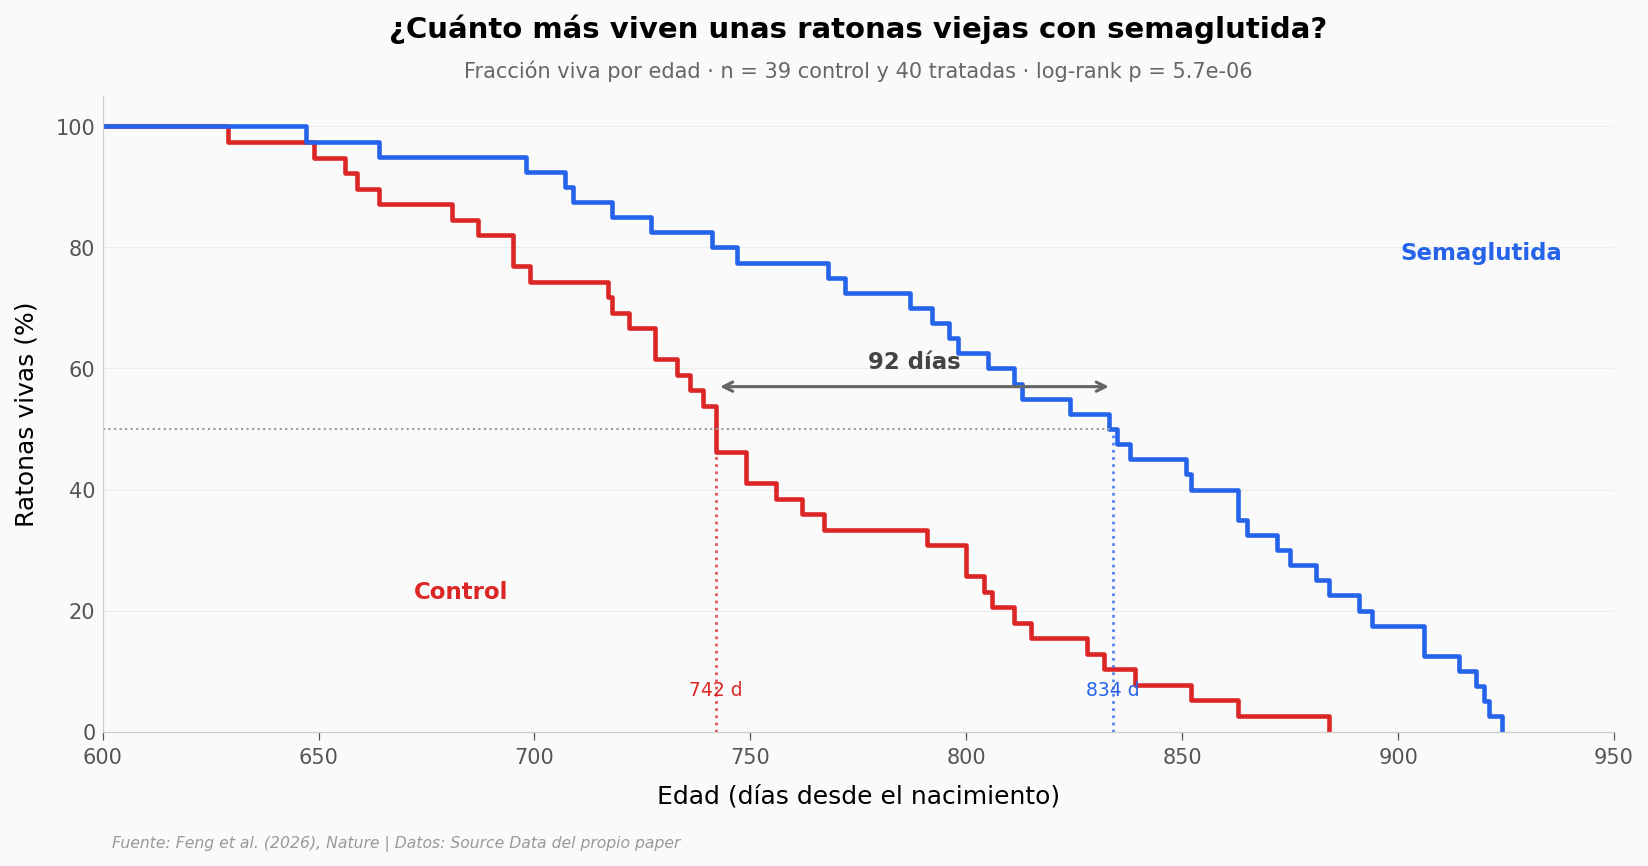

log-rank: chi2 = 20.601 (1 gl), p = 5.656e-06   |   el paper reporta p = 5,7e-06
d de Cohen = 0.995 (grande)
Shapiro-Wilk  control p = 0.6749   semaglutida p = 0.0490
Mann-Whitney (no asume normalidad): p = 9.89e-05
Rango intercuartílico  control: 708-802 d   semaglutida: 771-882 d
Ratona más longeva     control: 884 d   semaglutida: 924 d
Las curvas se separan por más de 10 puntos porcentuales a partir del día 681.
Separación máxima: 44.2 puntos porcentuales, en el día 767 (78% de tratadas vivas frente a 33% de control).


In [2]:
# Kaplan-Meier. Sin censura: el paper declara que ninguna ratona salió del
# estudio por causas ajenas al envejecimiento, así que la curva es la fracción
# viva en cada día y el log-rank se puede recalcular a mano.

def kaplan_meier(edades):
    dias = np.sort(np.unique(edades))
    n = len(edades)
    x, y = [0], [1.0]
    for dia in dias:
        x.append(dia)
        y.append((edades > dia).sum() / n)
    return np.array(x), np.array(y)

def log_rank(grupo_a, grupo_b):
    # Mantel-Cox sobre datos sin censura
    eventos = np.sort(np.unique(np.concatenate([grupo_a, grupo_b])))
    obs = esp = var = 0.0
    for t in eventos:
        n_a, n_b = (grupo_a >= t).sum(), (grupo_b >= t).sum()
        n = n_a + n_b
        d = (grupo_a == t).sum() + (grupo_b == t).sum()
        if n < 2:
            continue
        obs += (grupo_a == t).sum()
        esp += d * n_a / n
        var += d * (n_a / n) * (1 - n_a / n) * (n - d) / (n - 1)
    chi2 = (obs - esp) ** 2 / var
    return chi2, stats.chi2.sf(chi2, 1)

chi2, p_logrank = log_rank(vida_sema, vida_ctrl)
mediana_ctrl, mediana_sema = np.median(vida_ctrl), np.median(vida_sema)

fig, ax = plt.subplots(figsize=(13, 5.5))
for edades, color in [(vida_ctrl, COLOR_CONTROL), (vida_sema, COLOR_SEMA)]:
    x, y = kaplan_meier(edades)
    ax.step(x, y * 100, where='post', color=color, linewidth=2.2)

ax.set_xlim(600, 950)
ax.set_ylim(0, 105)
ax.text(672, 22, 'Control', fontsize=11, color=COLOR_CONTROL, fontweight='bold')
ax.text(938, 78, 'Semaglutida', fontsize=11, color=COLOR_SEMA, fontweight='bold', ha='right')

for mediana, color in [(mediana_ctrl, COLOR_CONTROL), (mediana_sema, COLOR_SEMA)]:
    ax.plot([mediana, mediana], [0, 50], color=color, linestyle=':', linewidth=1.3, alpha=0.8)
ax.plot([600, mediana_sema], [50, 50], color='#999999', linestyle=':', linewidth=1.0)
ax.annotate('', xy=(mediana_sema, 57), xytext=(mediana_ctrl, 57),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana_ctrl + mediana_sema) / 2, 60,
        '{:.0f} días'.format(mediana_sema - mediana_ctrl),
        fontsize=11, fontweight='bold', color='#444444', ha='center')
ax.text(mediana_ctrl, 6, '{:.0f} d'.format(mediana_ctrl), fontsize=9,
        color=COLOR_CONTROL, ha='center')
ax.text(mediana_sema, 6, '{:.0f} d'.format(mediana_sema), fontsize=9,
        color=COLOR_SEMA, ha='center')

ax.set_title('¿Cuánto más viven unas ratonas viejas con semaglutida?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Fracción viva por edad · n = {} control y {} tratadas · log-rank p = {:.1e}'.format(
            len(vida_ctrl), len(vida_sema), p_logrank),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad (días desde el nacimiento)')
ax.set_ylabel('Ratonas vivas (%)')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/supervivencia.png', dpi=200, bbox_inches='tight')
plt.show()

sd_combinada = np.sqrt(((len(vida_ctrl) - 1) * vida_ctrl.std(ddof=1) ** 2 +
                        (len(vida_sema) - 1) * vida_sema.std(ddof=1) ** 2) /
                       (len(vida_ctrl) + len(vida_sema) - 2))
d_cohen = (vida_sema.mean() - vida_ctrl.mean()) / sd_combinada
print('log-rank: chi2 = {:.3f} (1 gl), p = {:.3e}   |   el paper reporta p = 5,7e-06'.format(
    chi2, p_logrank))
print('d de Cohen = {:.3f} (grande)'.format(d_cohen))
print('Shapiro-Wilk  control p = {:.4f}   semaglutida p = {:.4f}'.format(
    stats.shapiro(vida_ctrl).pvalue, stats.shapiro(vida_sema).pvalue))
print('Mann-Whitney (no asume normalidad): p = {:.2e}'.format(
    stats.mannwhitneyu(vida_ctrl, vida_sema, alternative='two-sided').pvalue))
print('Rango intercuartílico  control: {:.0f}-{:.0f} d   semaglutida: {:.0f}-{:.0f} d'.format(
    np.percentile(vida_ctrl, 25), np.percentile(vida_ctrl, 75),
    np.percentile(vida_sema, 25), np.percentile(vida_sema, 75)))
print('Ratona más longeva     control: {:.0f} d   semaglutida: {:.0f} d'.format(
    vida_ctrl.max(), vida_sema.max()))

# ¿A qué edad se despegan las curvas? Primer día en que la brecha pasa de 10 puntos.
dias_comunes = np.arange(int(min(vida_ctrl.min(), vida_sema.min())),
                         int(max(vida_ctrl.max(), vida_sema.max())) + 1)
viva_ctrl = np.array([(vida_ctrl > d).mean() for d in dias_comunes])
viva_sema = np.array([(vida_sema > d).mean() for d in dias_comunes])
despegue = dias_comunes[np.argmax((viva_sema - viva_ctrl) >= 0.10)]
brecha = viva_sema - viva_ctrl
print('Las curvas se separan por más de 10 puntos porcentuales a partir del día {:.0f}.'.format(
    despegue))
print('Separación máxima: {:.1f} puntos porcentuales, en el día {:.0f}'
      ' ({:.0f}% de tratadas vivas frente a {:.0f}% de control).'.format(
          100 * brecha.max(), dias_comunes[brecha.argmax()],
          100 * viva_sema[brecha.argmax()], 100 * viva_ctrl[brecha.argmax()]))

Las dos curvas arrancan pegadas y se despegan el día 681, cuando la brecha pasa de 10 puntos porcentuales. A partir de ahí no vuelven a tocarse. En el día 767 la separación llega a su máximo: seguía viva el 78% de las tratadas frente al 33% de las control.

El desplazamiento no lo producen unas pocas ratonas excepcionales. El cuartil inferior del grupo tratado queda por encima de la mediana del control — la ratona tratada que estuvo entre el 25% que menos vivió duró más que la ratona control típica. La distribución entera se corrió; no se estiró solo la cola.

Dos cosas conviene anotar antes de seguir. El tamaño del efecto es grande (d de Cohen ≈ 1,0), pero la mediana sube 12,4% y la **media** sube 9,4%: el titular honesto es "cerca de una décima parte más de vida", no "el doble". Y el test de Shapiro-Wilk dice que las edades del grupo tratado no siguen una distribución normal, así que además del log-rank corrimos un Mann-Whitney, que no asume normalidad. Los dos apuntan al mismo lado.

## Vivir más no es lo mismo que vivir mejor

Un fármaco que estirara la vida dejando a la ratona postrada tres meses extra sería un mal negocio. Por eso el segundo grupo: a los 3 meses de tratamiento les midieron cuánto se movían, cuánto aguantaban colgadas de una rejilla, cuánto corrían antes de rendirse, si se acordaban de dónde estaba el hueco de escape, y cómo manejaban un pico de azúcar.

Son 14 paneles en el paper, pero **13 medidas independientes**: la distancia recorrida hasta el agotamiento en la cinta es exactamente el tiempo multiplicado por la velocidad fija de la cinta —12 m/min en las 20 ratonas—, así que no aporta información nueva. La graficamos una sola vez.

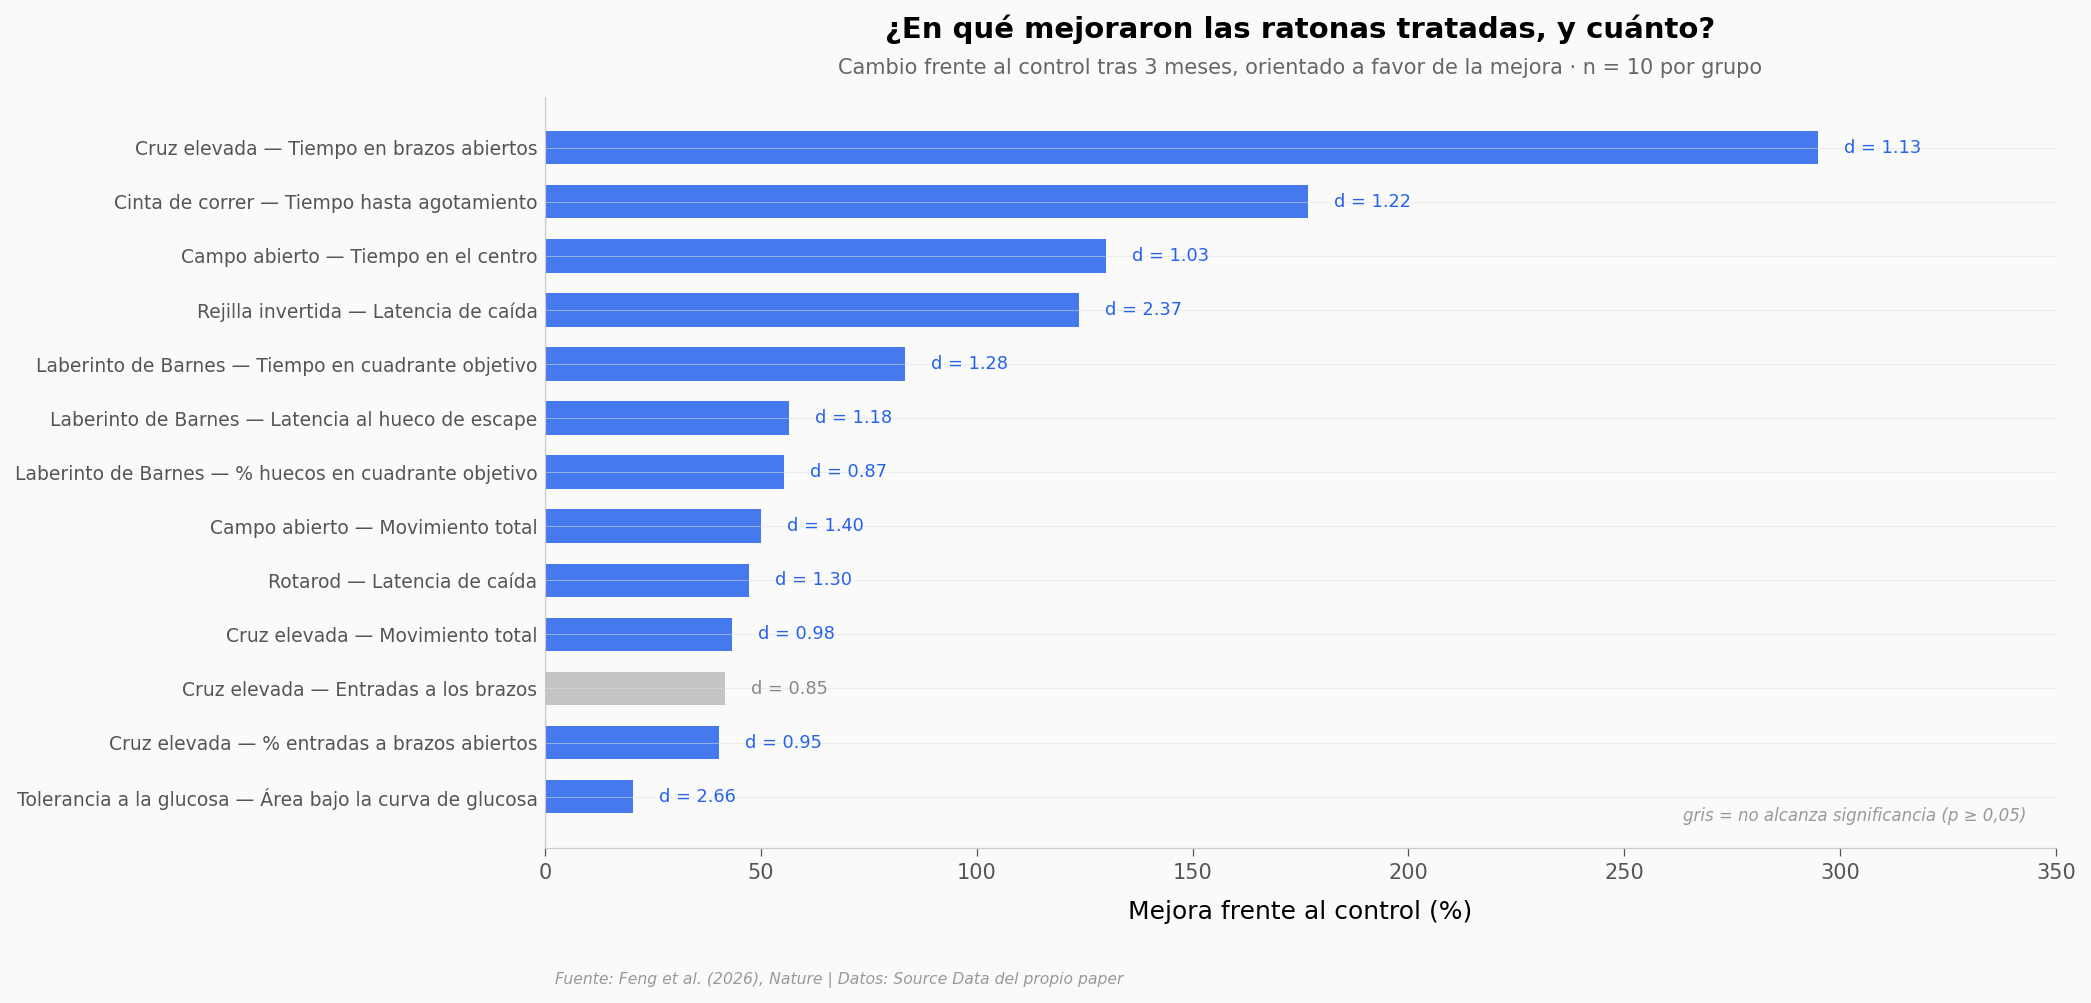

Medidas independientes graficadas: 13
Con p < 0.05: 12 de 13
Rango de |d| entre las significativas: 0.87 a 2.66

                 prueba                         medida  mejora_%        d              test_estadistico  p_valor
           Cruz elevada      Tiempo en brazos abiertos     294.9 1.134483 One-sided Mann-Whitney U test   0.0026
        Cinta de correr       Tiempo hasta agotamiento     176.7 1.219732 One-sided Mann-Whitney U test   0.0019
          Campo abierto            Tiempo en el centro     129.9 1.034157 One-sided Mann-Whitney U test   0.0116
      Rejilla invertida              Latencia de caída     123.7 2.368195    One-sided Student’s t-test 2.5×10-5
    Laberinto de Barnes   Tiempo en cuadrante objetivo      83.4 1.278574    One-sided Student’s t-test   0.0052
    Laberinto de Barnes    Latencia al hueco de escape      56.6 1.175894 One-sided Mann-Whitney U test   0.0102
    Laberinto de Barnes % huecos en cuadrante objetivo      55.3 0.869884               Beta reg

In [3]:
# El Source Data no imprime las unidades de cada prueba y las figuras del paper
# son imágenes. Por eso graficamos CAMBIO PORCENTUAL frente al control, que es
# comparable entre pruebas y no exige asumir unidades que no podemos verificar.
# Excluimos el panel o (distancia en cinta) = panel n × 12 m/min: es derivado.

bat = resumen[resumen.subfigura != 'o'].copy()

# Orientamos el signo: positivo = mejoró, sea cual sea la dirección de la prueba.
bat['signo'] = np.where(bat.direccion_mejora == 'mas_es_mejor', 1, -1)
bat['mejora_pct'] = bat.cambio_pct * bat.signo

def d_de_cohen(subfigura):
    datos = bateria[bateria.subfigura == subfigura]
    x = datos.loc[datos.grupo == 'Control', 'valor'].values
    y = datos.loc[datos.grupo == 'Semaglutida', 'valor'].values
    sd = np.sqrt(((len(x) - 1) * x.std(ddof=1) ** 2 + (len(y) - 1) * y.std(ddof=1) ** 2) /
                 (len(x) + len(y) - 2))
    return (y.mean() - x.mean()) / sd

bat['d_cohen'] = bat.subfigura.map(d_de_cohen)
bat['d_orientado'] = bat.d_cohen * bat.signo
bat['significativo'] = bat.p_num < ALFA
bat['etiqueta'] = bat.prueba + ' — ' + bat.medida
bat = bat.sort_values('mejora_pct')

fig, ax = plt.subplots(figsize=(13, 6.5))
colores = np.where(bat.significativo, COLOR_SEMA, COLOR_NEUTRO)
posiciones = np.arange(len(bat))
ax.barh(posiciones, bat.mejora_pct, color=colores, alpha=0.85, height=0.62)
ax.set_yticks(posiciones)
ax.set_yticklabels(bat.etiqueta, fontsize=9)
ax.axvline(0, color='#666666', linewidth=1.0)

for i, (valor, d_val, sig) in enumerate(zip(bat.mejora_pct, bat.d_orientado, bat.significativo)):
    ax.text(valor + 6, i, 'd = {:.2f}'.format(d_val), fontsize=8.5, va='center',
            color=COLOR_SEMA if sig else '#888888')

ax.set_xlim(0, 350)
ax.set_title('¿En qué mejoraron las ratonas tratadas, y cuánto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cambio frente al control tras 3 meses, orientado a favor de la mejora · n = 10 por grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Mejora frente al control (%)')
ax.text(0.98, 0.03, 'gris = no alcanza significancia (p ≥ 0,05)', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/bateria.png', dpi=200, bbox_inches='tight')
plt.show()

print('Medidas independientes graficadas:', len(bat))
print('Con p < {}: {} de {}'.format(ALFA, int(bat.significativo.sum()), len(bat)))
print('Rango de |d| entre las significativas: {:.2f} a {:.2f}'.format(
    bat.loc[bat.significativo, 'd_orientado'].min(),
    bat.loc[bat.significativo, 'd_orientado'].max()))
print()
print(bat[['prueba', 'medida', 'mejora_pct', 'd_orientado', 'test_estadistico', 'p_valor']]
      .rename(columns={'mejora_pct': 'mejora_%', 'd_orientado': 'd'})
      .sort_values('mejora_%', ascending=False).to_string(index=False))

Doce de las trece medidas separan a los dos grupos, con tamaños de efecto grandes según la convención habitual (|d| > 0,8). La que no llega es el conteo de entradas a los brazos de la cruz elevada: las tratadas entraron 41,8% más veces, pero con **p = 0,24** ese conteo no se distingue del azar.

Vale la pena detenerse ahí, porque dice algo sobre cómo se hizo el análisis. Un conteo de entradas no es una variable continua, así que los autores lo analizaron con regresión binomial negativa, el test propio de datos de conteo. Un test t sobre esos mismos diez pares de números habría dado p = 0,04 y un asterisco. Eligieron el test que le corresponde al tipo de dato, no el que daba el resultado bonito. Eso sí: el resto de la batería lo analizaron con tests **de una cola**, una decisión declarada de los autores que baja el listón frente a un test de dos colas.

## ¿Y si es solo que comen menos?

Aquí está la pregunta que hace que este paper no sea uno más sobre Ozempic. La semaglutida quita el hambre: las ratonas tratadas comieron 24% menos. Y comer menos —restricción calórica— es la intervención más replicada de toda la biología del envejecimiento. Así que el hallazgo podría ser trivial: el fármaco alarga la vida porque hace pasar hambre.

El equipo montó un tercer brazo con esa reducción exacta del 24%, y siguió a los tres grupos durante 5 meses midiendo nueve cosas en tres momentos: al empezar, a los 2 meses y a los 4.

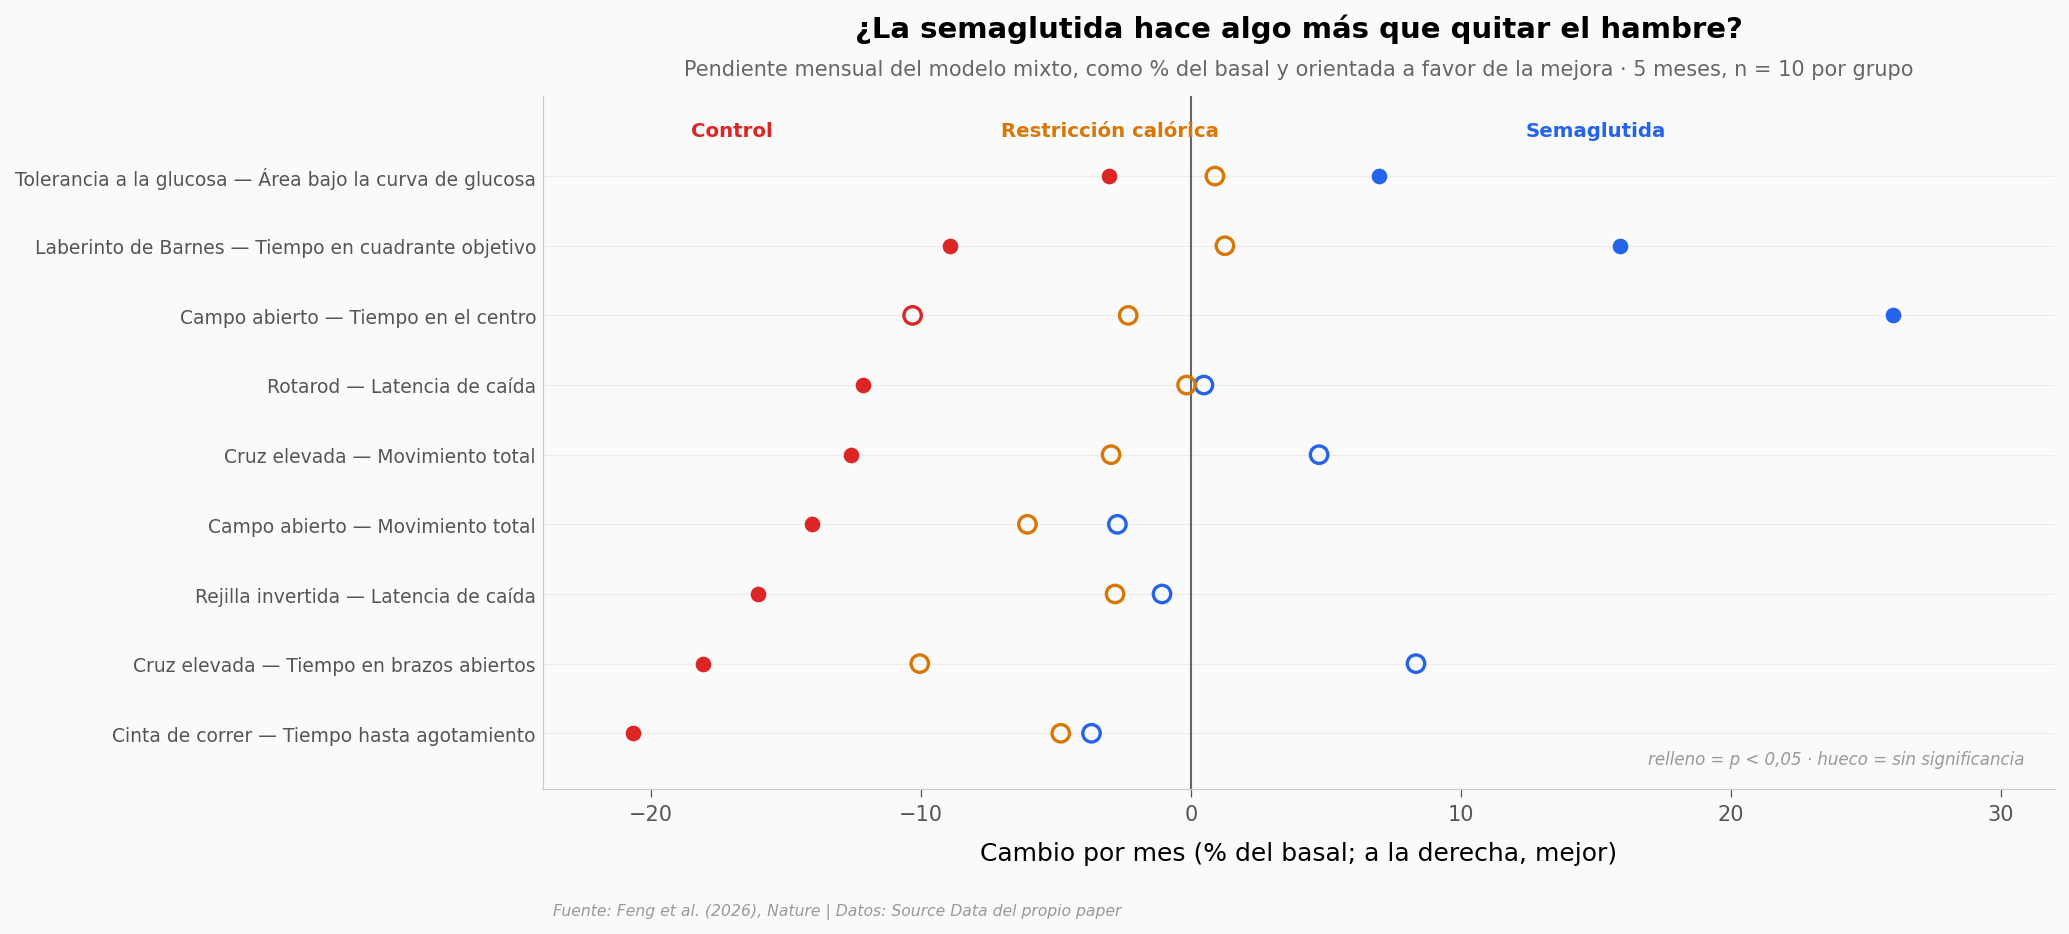

De las 9 medidas longitudinales, cuántas cambian de forma significativa:
  Control                empeora en 8   mejora sobre su propio basal en 0
  Semaglutida            empeora en 0   mejora sobre su propio basal en 3
  Restricción calórica   empeora en 0   mejora sobre su propio basal en 0

Medidas donde semaglutida y restricción calórica se separan (p ajustado < 0.05): 4 de 9
                 prueba                        medida p_ajustado  diferencia_pendiente
          Campo abierto           Tiempo en el centro     0.0172               31.7316
           Cruz elevada     Tiempo en brazos abiertos      0.043               11.7288
    Laberinto de Barnes  Tiempo en cuadrante objetivo     0.0298                5.2516
Tolerancia a la glucosa Área bajo la curva de glucosa     0.0116               -1.4758


In [4]:
# Cada prueba tiene su unidad, así que las pendientes del modelo mixto de los
# autores no son comparables en crudo. Las normalizamos: pendiente mensual como
# % del valor basal (mes 0, promedio de los tres grupos), orientada a favor de la
# mejora. Es una construcción NUESTRA para poner nueve pruebas en un mismo eje —
# no una métrica estándar del campo. El modelo mixto y sus p son los del paper.

basal = trayect[trayect.mes == 0].groupby('subfigura')['valor'].mean()
direccion = (trayect[['subfigura', 'direccion_mejora']].drop_duplicates()
             .set_index('subfigura')['direccion_mejora'])

pen = pendientes.copy()
pen['signo'] = pen.subfigura.map(lambda k: 1 if direccion[k] == 'mas_es_mejor' else -1)
pen['pct_mes'] = pen.pendiente_por_mes / pen.subfigura.map(basal).abs() * 100 * pen.signo
pen['etiqueta'] = pen.prueba + ' — ' + pen.medida
pen['significativo'] = pen.p_num < ALFA

orden = (pen[pen.grupo == 'Control'].sort_values('pct_mes')[['subfigura', 'etiqueta']]
         .reset_index(drop=True))
fila = {sf: i for i, sf in enumerate(orden.subfigura)}

estilos = [('Control', COLOR_CONTROL, 'Control'),
           ('Semaglutida', COLOR_SEMA, 'Semaglutida'),
           ('Restriccion calorica', COLOR_RC, 'Restricción calórica')]

fig, ax = plt.subplots(figsize=(13, 6))
ax.axvline(0, color='#666666', linewidth=1.0)
for grupo, color, _ in estilos:
    sub = pen[pen.grupo == grupo]
    ys = sub.subfigura.map(fila).values
    sig = sub.significativo.values
    ax.scatter(sub.pct_mes.values[sig], ys[sig], color=color, s=70,
               edgecolors='white', linewidths=0.8, zorder=5)
    ax.scatter(sub.pct_mes.values[~sig], ys[~sig], facecolors='none', edgecolors=color,
               s=70, linewidths=1.6, zorder=5)

ax.set_yticks(range(len(orden)))
ax.set_yticklabels(orden.etiqueta, fontsize=9)
ax.set_ylim(-0.8, len(orden) + 0.15)
ax.set_xlim(-24, 32)

# Etiquetas inline en el margen superior, separadas a mano: los tres puntos de la
# fila de arriba caen demasiado juntos para colgarles el nombre encima.
x_etiqueta = {'Control': -17, 'Restriccion calorica': -3, 'Semaglutida': 15}
for grupo, color, nombre in estilos:
    ax.text(x_etiqueta[grupo], len(orden) - 0.42, nombre, fontsize=9.5, color=color,
            fontweight='bold', ha='center')

ax.set_title('¿La semaglutida hace algo más que quitar el hambre?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Pendiente mensual del modelo mixto, como % del basal y orientada a favor de la mejora · 5 meses, n = 10 por grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Cambio por mes (% del basal; a la derecha, mejor)')
ax.text(0.98, 0.03, 'relleno = p < 0,05 · hueco = sin significancia', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/trayectorias.png', dpi=200, bbox_inches='tight')
plt.show()

print('De las {} medidas longitudinales, cuántas cambian de forma significativa:'.format(len(orden)))
for grupo, _, nombre in estilos:
    sub = pen[pen.grupo == grupo]
    empeora = int(((sub.pct_mes < 0) & sub.significativo).sum())
    mejora = int(((sub.pct_mes > 0) & sub.significativo).sum())
    print('  {:22s} empeora en {}   mejora sobre su propio basal en {}'.format(
        nombre, empeora, mejora))
print()
separan = pareadas[(pareadas.comparacion == 'Sema vs. CR') & (pareadas.p_num < ALFA)]
print('Medidas donde semaglutida y restricción calórica se separan (p ajustado < {}): {} de {}'.format(
    ALFA, len(separan), len(orden)))
print(separan[['prueba', 'medida', 'p_ajustado', 'diferencia_pendiente']].to_string(index=False))

El grupo control se deteriora en 8 de las 9 medidas. Los dos grupos intervenidos, en ninguna: tanto el fármaco como la dieta frenan la caída. Ahí van empatados, y ese es justamente el sentido de llamar a la semaglutida un *mimético de la restricción calórica* — algo que imita lo que hace comer menos.

La diferencia aparece en el otro extremo del eje. La dieta no mejora ninguna medida por encima de donde arrancó. La semaglutida mejora tres: el tiempo en el centro del campo abierto, el tiempo en el cuadrante objetivo del laberinto de Barnes y el manejo de la glucosa —exploración, memoria espacial y azúcar—. Y en cuatro medidas las dos trayectorias se separan de forma estadísticamente detectable.

Es el punto donde el paper deja de ser sobre el hambre. Hay que ser cuidadosos igual: son 10 ratonas por grupo durante cinco meses, y "no detectamos diferencia" entre fármaco y dieta en las otras cinco medidas no significa que no exista.

## ¿Qué tan lejos está una ratona de 834 días de lo normal?

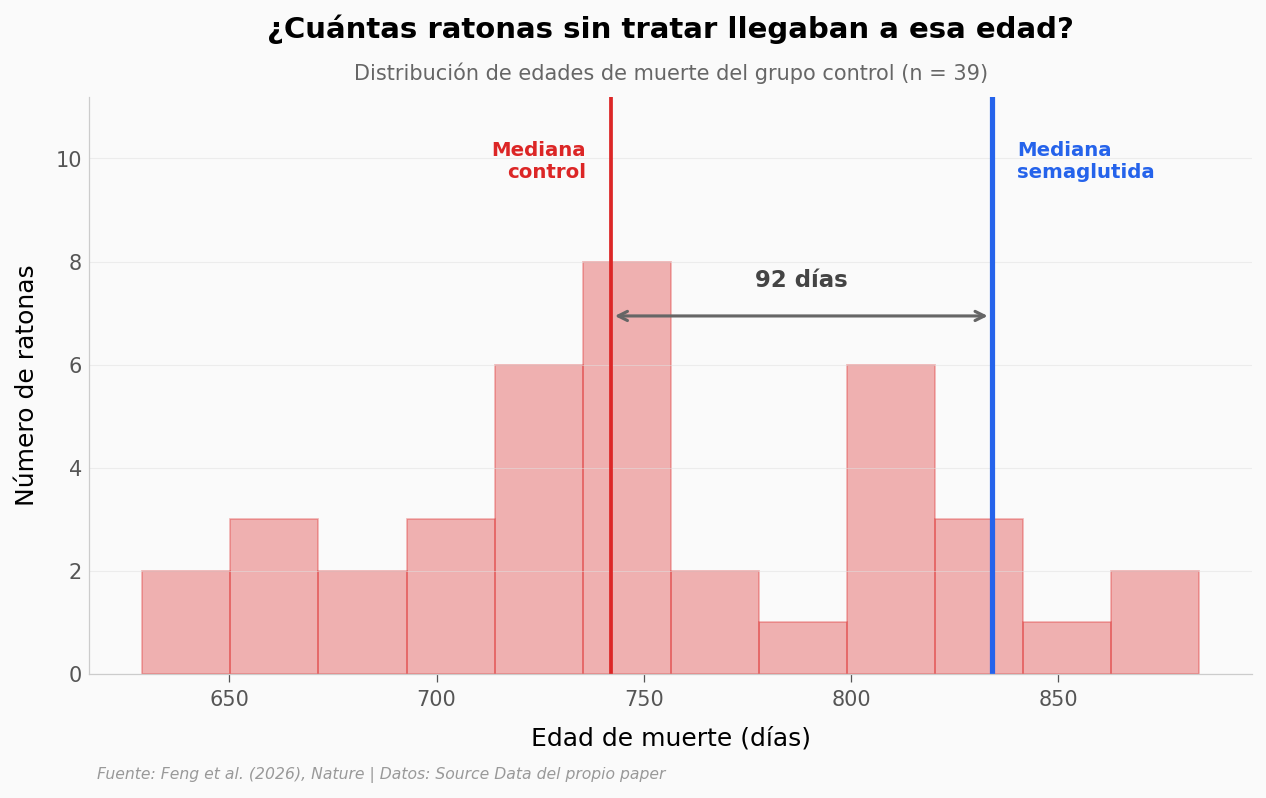

La mediana del grupo tratado (834 días) cae en el percentil 90 del grupo control.
Solo 4 de las 39 ratonas control (10%) llegaron a esa edad.
La ratona control más longeva vivió 884 días; la tratada más longeva, 924.


In [5]:
# Cierre cuantitativo: dónde cae la mediana del grupo tratado dentro de la
# distribución completa de edades de muerte del grupo control.

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, _ = ax.hist(vida_ctrl, bins=12, color=COLOR_CONTROL, alpha=0.35,
                     edgecolor=COLOR_CONTROL, linewidth=0.8)
y_max = n.max() * 1.4
ax.set_ylim(0, y_max)

ax.axvline(mediana_ctrl, color=COLOR_CONTROL, linewidth=1.8)
ax.axvline(mediana_sema, color=COLOR_SEMA, linewidth=2.5)
ax.annotate('', xy=(mediana_sema, y_max * 0.62), xytext=(mediana_ctrl, y_max * 0.62),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana_ctrl + mediana_sema) / 2, y_max * 0.67,
        '{:.0f} días'.format(mediana_sema - mediana_ctrl),
        fontsize=11, fontweight='bold', color='#444444', ha='center')
ax.text(mediana_ctrl - 6, y_max * 0.86, 'Mediana\ncontrol', fontsize=9.5,
        color=COLOR_CONTROL, fontweight='bold', ha='right')
ax.text(mediana_sema + 6, y_max * 0.86, 'Mediana\nsemaglutida', fontsize=9.5,
        color=COLOR_SEMA, fontweight='bold', ha='left')

percentil = 100 * (vida_ctrl < mediana_sema).mean()
por_encima = int((vida_ctrl >= mediana_sema).sum())
ax.set_title('¿Cuántas ratonas sin tratar llegaban a esa edad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución de edades de muerte del grupo control (n = {})'.format(len(vida_ctrl)),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Edad de muerte (días)')
ax.set_ylabel('Número de ratonas')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print('La mediana del grupo tratado ({:.0f} días) cae en el percentil {:.0f} del grupo control.'.format(
    mediana_sema, percentil))
print('Solo {} de las {} ratonas control ({:.0f}%) llegaron a esa edad.'.format(
    por_encima, len(vida_ctrl), 100 * por_encima / len(vida_ctrl)))
print('La ratona control más longeva vivió {:.0f} días; la tratada más longeva, {:.0f}.'.format(
    vida_ctrl.max(), vida_sema.max()))

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La semaglutida alargó la vida de ratonas viejas | ✅ | Mediana 742 → 834 días (+92 d, +12,4%); media 750,5 → 820,8 días (+9,4%). Log-rank recalculado por nosotros: χ² = 20,60, p = 5,7 × 10⁻⁶, igual al del paper. d de Cohen = 1,00 |
| El efecto no lo producen unas pocas ratonas excepcionales | ✅ | El cuartil inferior tratado (771 d) supera la mediana control (742 d): la distribución entera se desplaza. La mediana tratada cae en el percentil 90 del control — solo 4 de las 39 control (10%) llegaron a esa edad |
| Mejoró la función física y cognitiva tras 3 meses | ✅ | 12 de 13 medidas independientes con p < 0,05, todas con \|d\| > 0,8. Con la advertencia de que son tests de una cola, decisión declarada de los autores |
| Todas las medidas de la batería mejoraron | ⚠️ | El conteo de entradas a los brazos de la cruz elevada no llega: p = 0,24 con regresión binomial negativa. Lo mostramos en gris, no lo escondemos |
| La semaglutida hace algo más que replicar la restricción calórica | ⚠️ | Los datos apuntan a eso: mejora 3 de 9 medidas sobre su propio basal frente a 0 de la dieta, y se separa de ella en 4 con p ajustado < 0,05. Pero con n = 10 por grupo y 5 meses, "no detectamos diferencia" en las otras 5 no equivale a "no hay diferencia" |
| Frenar el deterioro es mérito exclusivo del fármaco | ❌ | No. En frenar la caída van empatados: ninguno de los dos grupos intervenidos empeora de forma significativa en ninguna medida, mientras el control empeora en 8 de 9 |
| Esto pasa en humanos | ❌ | No hay datos humanos aquí. El propio paper pide un ensayo clínico largo diseñado para medir envejecimiento |

> **Limitaciones.** (1) Solo ratonas **hembra** C57BL/6, una sola cepa; el paper lo justifica por la agresión entre machos, pero no hay datos de machos. (2) Una sola dosis probada (10 nmol/kg/día): no sabemos si el efecto depende de ella. (3) La cohorte de longevidad y la de fisiología son **grupos distintos** — las ratonas que vivieron más no son las mismas a las que se midió la fuerza. (4) El mecanismo es hipótesis, no resultado: el abstract dice que el marco propuesto *podría* ayudar a explicar los efectos, no que los explique. (5) La batería de los 3 meses usó tests de una cola. (6) El Source Data no publica las unidades de cada prueba, así que la graficamos como cambio porcentual y no afirmamos unidades que no podemos verificar. (7) La pendiente normalizada como % del basal es una construcción nuestra para comparar nueve pruebas en un mismo eje, no una métrica estándar del campo; el modelo mixto y sus valores p son los de los autores.

## Ahora tú

1. **¿Sobrevive el resultado si le quitas la ratona más longeva a cada grupo?** El log-rank es sensible a las colas. Pista: `log_rank(np.sort(vida_sema)[:-1], np.sort(vida_ctrl)[:-1])`.
2. **¿Cuánto de la ventaja en glucosa está en el pico y cuánto en el punto de partida?** La celda de abajo separa las dos cosas: compara la glucemia del minuto 0 con el área bajo la curva completa.
3. **¿Qué pasa si le exiges dos colas a la batería?** Varios tests de la tabla son de una cola. Pista: recorre `bateria` con `stats.ttest_ind(y, x)` y cuenta cuántos siguen por debajo de 0,05.

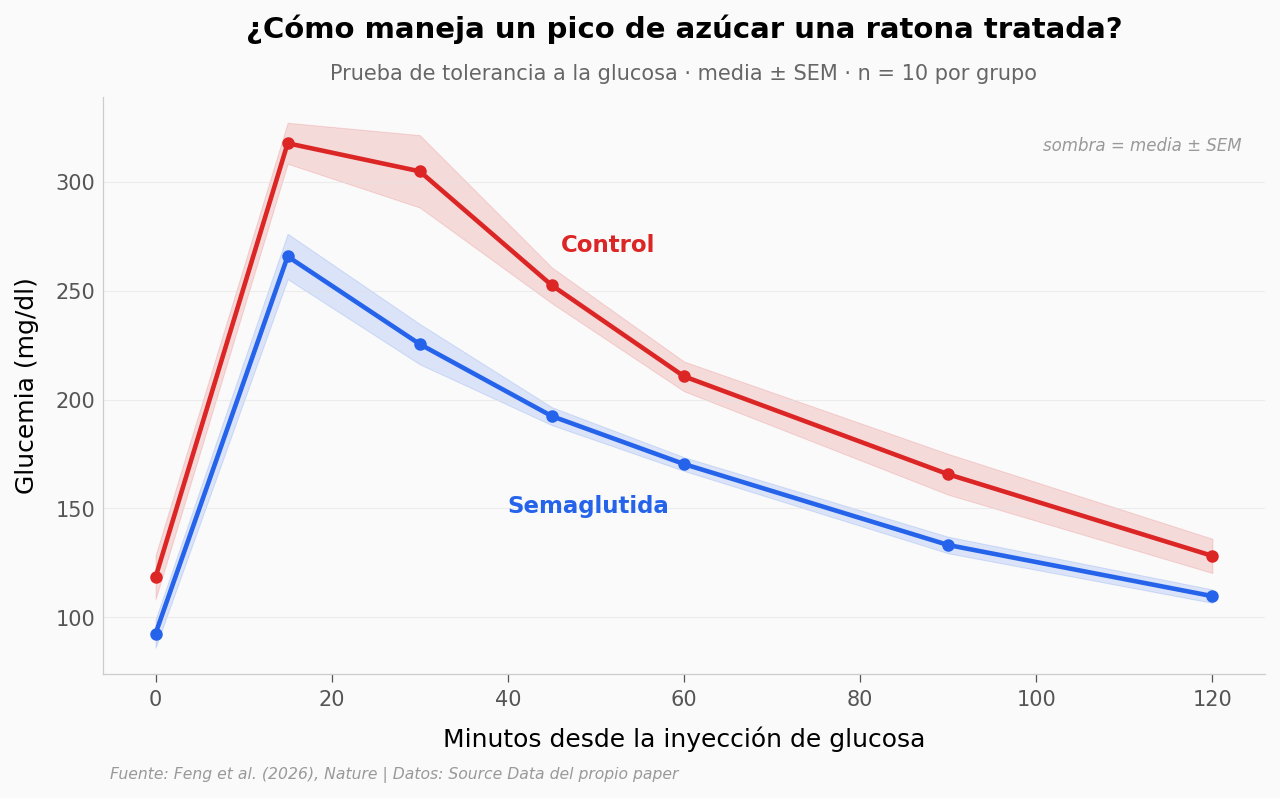

Área bajo la curva  control: 25651   semaglutida: 20425   (-20.4%)
  d de Cohen = -2.66  |  Mann-Whitney p = 2.45e-04
Glucemia en ayunas  control: 118.4 mg/dl   semaglutida: 92.5 mg/dl   (-21.9%)
Pico a los 15 min   control: 317.8 mg/dl   semaglutida: 265.8 mg/dl   (-16.4%)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿la ventaja en glucosa está en el pico o en el punto de partida?

trapecio = getattr(np, 'trapezoid', None) or np.trapz

areas = []
for (grupo, raton), datos in glucosa.sort_values('tiempo_min').groupby(['grupo', 'raton']):
    areas.append({'grupo': grupo, 'raton': raton,
                  'auc': trapecio(datos.glucosa_mg_dl.values, datos.tiempo_min.values),
                  'basal': datos.glucosa_mg_dl.iloc[0]})
areas = pd.DataFrame(areas)

curva = glucosa.groupby(['grupo', 'tiempo_min'])['glucosa_mg_dl'].agg(['mean', 'sem']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for grupo, color in [('Control', COLOR_CONTROL), ('Semaglutida', COLOR_SEMA)]:
    sub = curva[curva.grupo == grupo]
    ax.plot(sub.tiempo_min, sub['mean'], color=color, linewidth=2.2, marker='o', markersize=5)
    ax.fill_between(sub.tiempo_min, sub['mean'] - sub['sem'], sub['mean'] + sub['sem'],
                    color=color, alpha=0.15)
ax.text(46, 268, 'Control', fontsize=11, color=COLOR_CONTROL, fontweight='bold')
ax.text(40, 148, 'Semaglutida', fontsize=11, color=COLOR_SEMA, fontweight='bold')
ax.set_title('¿Cómo maneja un pico de azúcar una ratona tratada?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Prueba de tolerancia a la glucosa · media ± SEM · n = 10 por grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Minutos desde la inyección de glucosa')
ax.set_ylabel('Glucemia (mg/dl)')
ax.text(0.98, 0.9, 'sombra = media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/glucosa.png', dpi=200, bbox_inches='tight')
plt.show()

auc_ctrl = areas.loc[areas.grupo == 'Control', 'auc'].values
auc_sema = areas.loc[areas.grupo == 'Semaglutida', 'auc'].values
basal_ctrl = areas.loc[areas.grupo == 'Control', 'basal'].values
basal_sema = areas.loc[areas.grupo == 'Semaglutida', 'basal'].values
sd_auc = np.sqrt(((len(auc_ctrl) - 1) * auc_ctrl.std(ddof=1) ** 2 +
                  (len(auc_sema) - 1) * auc_sema.std(ddof=1) ** 2) /
                 (len(auc_ctrl) + len(auc_sema) - 2))

print('Área bajo la curva  control: {:.0f}   semaglutida: {:.0f}   ({:+.1f}%)'.format(
    auc_ctrl.mean(), auc_sema.mean(), 100 * (auc_sema.mean() / auc_ctrl.mean() - 1)))
print('  d de Cohen = {:.2f}  |  Mann-Whitney p = {:.2e}'.format(
    (auc_sema.mean() - auc_ctrl.mean()) / sd_auc,
    stats.mannwhitneyu(auc_ctrl, auc_sema).pvalue))
print('Glucemia en ayunas  control: {:.1f} mg/dl   semaglutida: {:.1f} mg/dl   ({:+.1f}%)'.format(
    basal_ctrl.mean(), basal_sema.mean(), 100 * (basal_sema.mean() / basal_ctrl.mean() - 1)))
print('Pico a los 15 min   control: {:.1f} mg/dl   semaglutida: {:.1f} mg/dl   ({:+.1f}%)'.format(
    glucosa.loc[(glucosa.grupo == 'Control') & (glucosa.tiempo_min == 15), 'glucosa_mg_dl'].mean(),
    glucosa.loc[(glucosa.grupo == 'Semaglutida') & (glucosa.tiempo_min == 15), 'glucosa_mg_dl'].mean(),
    100 * (glucosa.loc[(glucosa.grupo == 'Semaglutida') & (glucosa.tiempo_min == 15), 'glucosa_mg_dl'].mean() /
           glucosa.loc[(glucosa.grupo == 'Control') & (glucosa.tiempo_min == 15), 'glucosa_mg_dl'].mean() - 1)))

## Fuentes

**Paper**: [Late-life semaglutide treatment slows ageing and extends lifespan in female mice](https://doi.org/10.1038/s41586-026-10940-7)  
*Nature, 2026-09-02*

**Source Data**: [Source Data Fig. 1 — supervivencia y bateria fisiologica](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10940-7/MediaObjects/41586_2026_10940_MOESM6_ESM.xlsx)

**Source Data**: [Source Data Fig. 5 — comparacion directa contra restriccion calorica](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-10940-7/MediaObjects/41586_2026_10940_MOESM9_ESM.xlsx)

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [El Lab](https://cienciaamordiscos.com) — Ciencia a Mordiscos. Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*